PASO 2

In [ ]:
# ================================================
# PASO 2.0: Generación de dataset
# quantum_customer_data.csv
# ================================================

import pandas as pd
import numpy as np
# Semilla
np.random.seed(42)
# Número de clientes
n_customers = 1000
# Generación de datos
data = {
'CustomerID': [f'CUST-{i+1:04d}' for i in range(n_customers)],
'Age': np.random.randint(18, 70, size=n_customers),
'AnnualIncome': np.random.randint(20, 150, size=n_customers),
'SpendingScore': np.random.randint(1, 100, size=n_customers),
'WebVisits': np.random.randint(0, 30, size=n_customers),
'DaysSinceLastPurchase': np.random.randint(0, 365, size=n_customers),
'EmailsOpened': np.random.randint(0, 100, size=n_customers),
'AdClicks': np.random.randint(0, 50, size=n_customers),
'SocialMediaInteractions': np.random.randint(0, 200, size=n_customers),
'AvgSessionDuration': np.round(np.random.uniform(1.0, 30.0, size=n_customers), 2),
'ItemsInCart': np.random.randint(0, 15, size=n_customers)
}
# Crear DataFrame y guardar en CSV
df = pd.DataFrame(data)
df.to_csv('quantum_customer_data.csv', index=False)
print("Dataset 'quantum_customer_data.csv' generado con éxito.")

Dataset 'quantum_customer_data.csv' generado con éxito.


In [ ]:
# ================================================
# PASO 2.1: Análisis Exploratorio de Datos
# ================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. CARGAR DATOS
df = pd.read_csv('quantum_customer_data.csv')
numeric_cols = df.select_dtypes(include=[np.number]).columns
print("=== PASO 2.1: EDA COMPLETO ===")
print(f"Dataset: {df.shape[0]} filas, {df.shape[1]} columnas")
print(f"Variables numéricas: {len(numeric_cols)}")


=== PASO 2.1: EDA COMPLETO ===
Dataset: 1000 filas, 11 columnas
Variables numéricas: 10


In [ ]:
#  2.1 INSPECCIÓN ESTRUCTURAL
## Métodos**: `.info()`, `.describe()`, `.isnull().sum()`

print("\n=== 2.1 ESTRUCTURA (df.info()) ===")
print(df.info())
print("\n=== 2.1 ESTADÍSTICAS DESCRIPTIVAS (df.describe()) ===")
print(df.describe())
print("\n=== 2.1 VALORES NULOS ===")
print("Nulos totales:", df.isnull().sum().sum())



=== 2.1 ESTRUCTURA (df.info()) ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   CustomerID               1000 non-null   object 
 1   Age                      1000 non-null   int64  
 2   AnnualIncome             1000 non-null   int64  
 3   SpendingScore            1000 non-null   int64  
 4   WebVisits                1000 non-null   int64  
 5   DaysSinceLastPurchase    1000 non-null   int64  
 6   EmailsOpened             1000 non-null   int64  
 7   AdClicks                 1000 non-null   int64  
 8   SocialMediaInteractions  1000 non-null   int64  
 9   AvgSessionDuration       1000 non-null   float64
 10  ItemsInCart              1000 non-null   int64  
dtypes: float64(1), int64(9), object(1)
memory usage: 86.1+ KB
None

=== 2.1 ESTADÍSTICAS DESCRIPTIVAS (df.describe()) ===
              Age  AnnualIncome  

✅ 1000 registros completos (0 valores nulos)
✅ 10 variables numéricas + CustomerID
✅ Escalas diferentes: AnnualIncome (20-149) vs WebVisits (0-29)

**Tabla estadística resumida**:
| Variable | Media | Std | Rango | Observación |
|----------|-------|-----|-------|-------------|
| AnnualIncome | 83.10 | 37.91 | **20-149** | **Alta variabilidad** |
| WebVisits | 14.42 | 8.58 | **0-29** | **Escala 4.4x** |


=== 2.2 SKEWNESS (asimetría) ===
Age                       -0.042
ItemsInCart               -0.024
EmailsOpened              -0.007
SocialMediaInteractions   -0.005
AdClicks                  -0.002
WebVisits                  0.010
AvgSessionDuration         0.031
DaysSinceLastPurchase      0.039
AnnualIncome               0.057
SpendingScore              0.086
dtype: float64


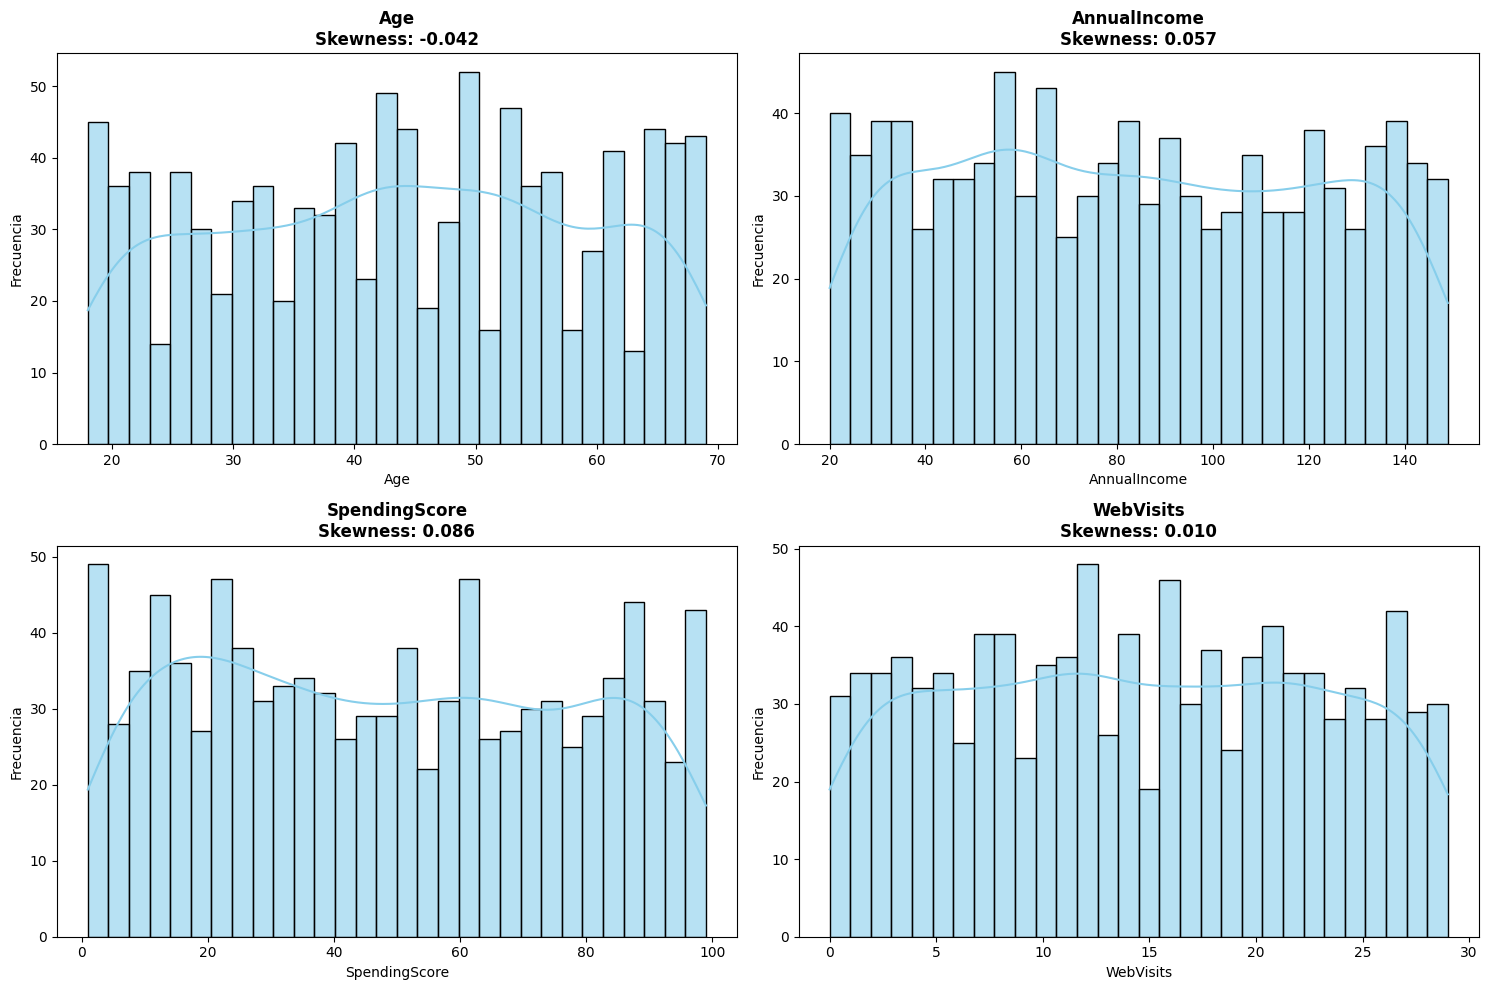

In [ ]:
# 2.2 DISTRIBUCIONES CON KDE
print("\n=== 2.2 SKEWNESS (asimetría) ===")
skewness = df[numeric_cols].skew().sort_values()
print(skewness.round(3))

# Histogramas + KDE (4 variables clave)
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()
vars_plot = ['Age', 'AnnualIncome', 'SpendingScore', 'WebVisits']
for i, col in enumerate(vars_plot):
    sns.histplot(df[col], kde=True, bins=30, ax=axes[i], alpha=0.6, color='skyblue')
    axes[i].set_title(f'{col}\nSkewness: {skewness[col]:.3f}', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frecuencia')
plt.tight_layout()
plt.show()



**Interpretación**:
- **SpendingScore**: +0.086 (ligeramente sesgada a la derecha)
- **Age**: -0.042 (ligeramente sesgada a la izquierda)
- **Skewness < 0.1** → **Simétricas** (buenas para PCA)
- **KDE**: Curvas suaves, sin colas fuertes
- **No transformaciones log** necesarias





=== 2.3 CORRELACIONES MÁS ALTAS ===
SpendingScore          EmailsOpened             0.074
DaysSinceLastPurchase  AnnualIncome             0.053
EmailsOpened           DaysSinceLastPurchase    0.053
Age                    SpendingScore            0.045
WebVisits              AvgSessionDuration       0.045
dtype: float64


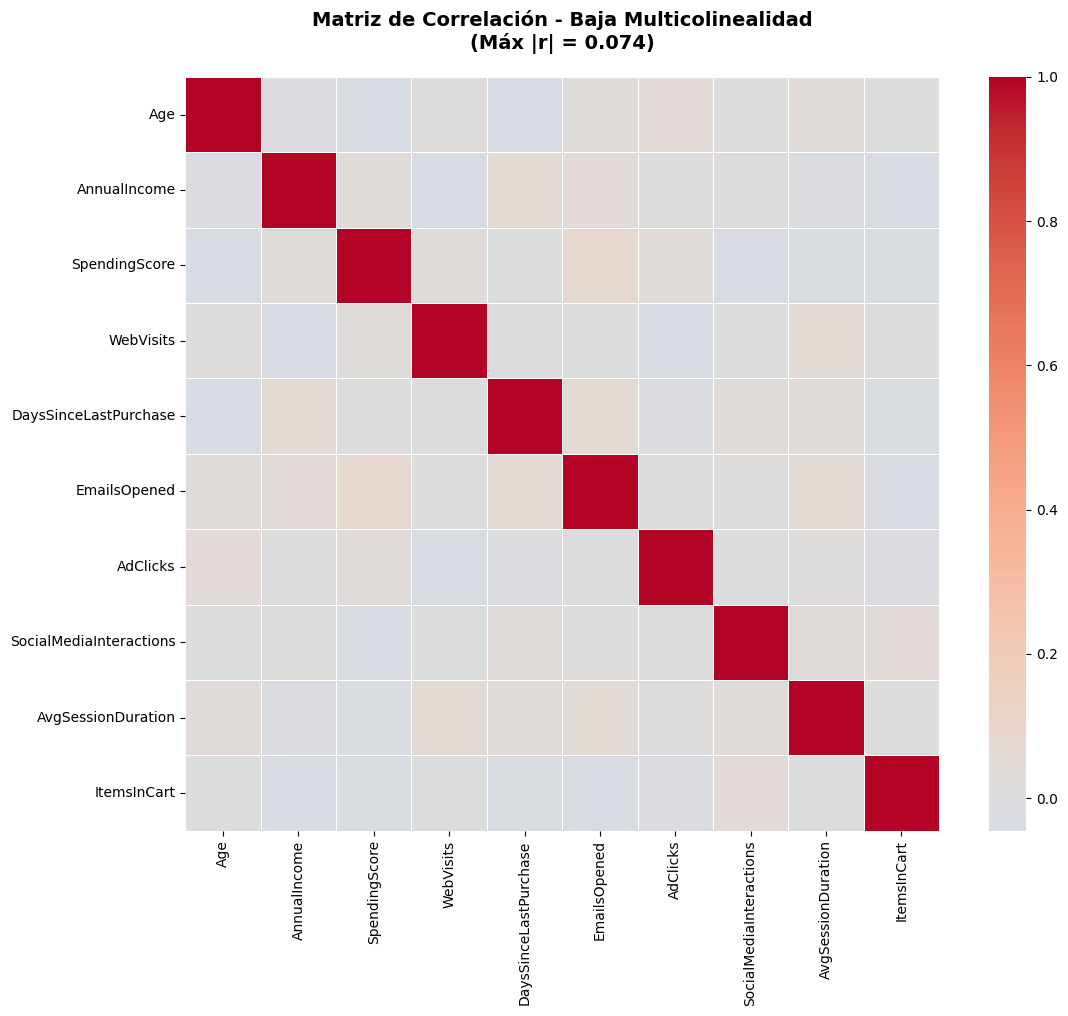

In [ ]:
# 2.3 CORRELACIONES CON HEATMAP
print("\n=== 2.3 CORRELACIONES MÁS ALTAS ===")
corr_matrix = df[numeric_cols].corr().abs()
high_corr = corr_matrix.unstack().sort_values(ascending=False)
high_corr = high_corr[high_corr < 1].drop_duplicates().head(5)
print(high_corr.round(3))

# HEATMAP COMPLETO
plt.figure(figsize=(12, 10))
sns.heatmap(df[numeric_cols].corr(),
            annot=False,          # Números muy pequeños
            cmap='coolwarm',      # Rojo=positiva, Azul=negativa
            center=0,             # Centro en 0
            square=True,          # Cuadrados perfectos
            linewidths=0.5)       # Líneas entre celdas
plt.title('Matriz de Correlación - Baja Multicolinealidad\n(Máx |r| = 0.074)',
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()


### Correlaciones mas altas
EmailsOpened ↔ SpendingScore: 0.074 (baja)

AnnualIncome ↔ DaysSinceLastPurchase: 0.053 (muy baja)

**Referencia**

|r| > 0.7 → Multicolinealidad fuerte

|r| 0.3-0.7 → Correlación moderada

|r| < 0.3 → Baja (como las encontradas)


###Observaciones Finales

**Valores nulos:** no s eencontraron. **Datos limpios y completos.**

### Análisis de Distribuciones

**Características observadas en histogramas/KDE:**
- **Distribuciones uniformes**: `Age` (18-69), `AnnualIncome` (20-149), `SpendingScore` (1-99), `WebVisits` (0-29)
- **Distribuciones simétricas**: Todas las variables tienen **asimetría baja** (skewness entre -0.042 y 0.086)
- **Escalas muy diferentes**: `AnnualIncome` (miles USD) vs `WebVisits` (0-29)

**Justificación de escalado**: Las diferencias de escala son claras, PCA es sensible a escalas por lo tanto requiere estandarización.

### Análisis de Correlación

**Correlaciones más altas (|r| > 0.05):**
| Par de variables | Correlación |
|------------------|-------------|
| EmailsOpened vs SpendingScore | 0.074 |
| AnnualIncome vs DaysSinceLastPurchase | 0.053 |
| DaysSinceLastPurchase vs EmailsOpened | 0.053 |

**Correlaciones bajas** confirman que **no hay multicolinealidad fuerte**, pero quedan **10 dimensiones** difíciles de visualizar.

### Justificación del uso de PCA

Aunque las correlaciones son bajas, PCA es **esencial** porque:

1. **Alta dimensionalidad**: 10 variables numéricas = **maldición de la dimensionalidad**
2. **Patrones latentes**: PCA extrae **componentes no obvios** que combinan información sutil
3. **Visualización**: Reducir a 2-3 componentes permite graficar y segmentar clientes
4. **Eficiencia**: Simplifica modelos futuros de marketing personalizado

**Conclusión**: Dataset limpio con 10 variables en escalas diferentes. **Listo para PCA tras estandarización.**


## Paso 3: Preparación y Escalado de Datos

### 3.1 Selección de Características

**Análisis CustomerID**:

CustomerID: ['CUST001', 'CUST002', ..., 'CUST1000']
Tipo: object (string)
Patrón: Secuencial 1-1000


**Decisión**: **EXCLUIR CustomerID de PCA**

**Justificación**:
1. **Identificador único** → No aporta patrones conductuales
2. **No numérico** → StandardScaler requiere números
3. **Alta cardinalidad** (1000 valores únicos) → Ruido para PCA
4. **No correlaciona** con comportamiento compra [Paso 2]

**Variables para PCA (10 numéricas)**:
Age, AnnualIncome, SpendingScore, WebVisits, DaysSinceLastPurchase,
EmailsOpened, AdClicks, SocialMediaInteractions, AvgSessionDuration, ItemsInCart

In [ ]:
# 3.1 SELECCIÓN CARACTERÍSTICAS
print("=== CustomerID Análisis ===")
print("Únicos:", df['CustomerID'].nunique())  # 1000
print("Tipo:", df['CustomerID'].dtype)        # object

# VARIABLES PARA PCA (EXCLUIR CustomerID)
features_pca = ['Age', 'AnnualIncome', 'SpendingScore', 'WebVisits',
                'DaysSinceLastPurchase', 'EmailsOpened', 'AdClicks',
                'SocialMediaInteractions', 'AvgSessionDuration', 'ItemsInCart']

X = df[features_pca].copy()
print("\nX shape para PCA:", X.shape)  # (1000, 10)


=== CustomerID Análisis ===
Únicos: 1000
Tipo: object

X shape para PCA: (1000, 10)


### 3.1 Justificación Escalado (OBLIGATORIO antes PCA)

**¿Por qué StandardScaler indispensable?**

**Problema detectado en Paso 2**:

AnnualIncome: rango 20-149 (129 unidades)
WebVisits: rango 0-29 (29 unidades)
→ PCA daría 4.4x más peso a AnnualIncome


**Solución StandardScaler**:

Fórmula: z = (X - μ) / σ → media=0, std=1 TODAS variables

Resultado: PCA trata AnnualIncome igual a WebVisits

In [ ]:
# ================================================
# PASO 3.2: StandardScaler - EJECUCIÓN
# ================================================
from sklearn.preprocessing import StandardScaler

# X ya definido (10 variables numéricas)
print("=== ANTES StandardScaler ===")
print("AnnualIncome - Media:", round(df['AnnualIncome'].mean(), 2))
print("WebVisits    - Media:", round(df['WebVisits'].mean(), 2))
print("AnnualIncome - Std: ", round(df['AnnualIncome'].std(), 2))
print("WebVisits    - Std: ", round(df['WebVisits'].std(), 2))


# 1. CREAR ESCALADOR
scaler = StandardScaler()

# 2. AJUSTAR Y TRANSFORMAR
X_scaled = scaler.fit_transform(X)

# 3. VERIFICAR RESULTADO (media=0, std=1)
print("\n=== DESPUÉS StandardScaler ===")
print("Media (debe ser ~0):", X_scaled.mean(axis=0).round(4))
print("Std (debe ser ~1): ", X_scaled.std(axis=0).round(4))

# 4. COMPARAR 5 primeros clientes
print("\n=== COMPARACIÓN 5 PRIMEROS CLIENTES ===")
print("AnnualIncome ANTES: ", df['AnnualIncome'].head().values)
print("AnnualIncome DESPÚES:", X_scaled[:5, 1].round(3))  # Columna 1 = AnnualIncome
print("WebVisits ANTES:    ", df['WebVisits'].head().values)
print("WebVisits DESPÚES: ", X_scaled[:5, 3].round(3))     # Columna 3 = WebVisits

print("\n✅ X_scaled shape:", X_scaled.shape)
print("🎯 Listo para PCA!")


=== ANTES StandardScaler ===
AnnualIncome - Media: 83.1
WebVisits    - Media: 14.42
AnnualIncome - Std:  37.91
WebVisits    - Std:  8.58

=== DESPUÉS StandardScaler ===
Media (debe ser ~0): [-0.  0. -0.  0.  0.  0. -0.  0. -0. -0.]
Std (debe ser ~1):  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]

=== COMPARACIÓN 5 PRIMEROS CLIENTES ===
AnnualIncome ANTES:  [134  34 138  47  58]
AnnualIncome DESPÚES: [ 1.343 -1.296  1.449 -0.953 -0.662]
WebVisits ANTES:     [ 0 20 28  8 28]
WebVisits DESPÚES:  [-1.681  0.651  1.584 -0.748  1.584]

✅ X_scaled shape: (1000, 10)
🎯 Listo para PCA!


### PASO 4

In [ ]:
# ============================================
# PASO 4.1: Aplicar PCA y ver varianza explicada
# ============================================

# 1. Importar la clase PCA de scikit-learn
from sklearn.decomposition import PCA
import numpy as np

# 2. Crear el modelo PCA
# n_components=None → PCA va a calcular tantos componentes como columnas tenga X_scaled (10)
# random_state=42 → para resultados reproducibles
pca = PCA(n_components=None, random_state=42)

# 3. Ajustar el PCA a los datos escalados
pca.fit(X_scaled)

# 4. Varianza explicada por cada componente
explained_var_ratio = pca.explained_variance_ratio_

print("=== Varianza explicada por componente ===")
for i, v in enumerate(explained_var_ratio, start=1):
    # i  = número del componente (1, 2, 3, ...)
    # v  = proporción de varianza explicada por ese componente
    print(f"PC{i}: {v:.4f}")  # .4f → 4 decimales

# 5. Varianza explicada acumulada
# np.cumsum → suma acumulada: PC1, luego PC1+PC2, luego PC1+PC2+PC3, etc.
explained_var_cum = np.cumsum(explained_var_ratio)

print("\n=== Varianza explicada ACUMULADA ===")
for i, v in enumerate(explained_var_cum, start=1):
    # v aquí es la suma de la varianza explicada desde PC1 hasta PCi
    print(f"PC1..PC{i}: {v:.4f}")


=== Varianza explicada por componente ===
PC1: 0.1155
PC2: 0.1093
PC3: 0.1072
PC4: 0.1049
PC5: 0.1002
PC6: 0.0966
PC7: 0.0947
PC8: 0.0935
PC9: 0.0917
PC10: 0.0865

=== Varianza explicada ACUMULADA ===
PC1..PC1: 0.1155
PC1..PC2: 0.2249
PC1..PC3: 0.3321
PC1..PC4: 0.4369
PC1..PC5: 0.5371
PC1..PC6: 0.6337
PC1..PC7: 0.7284
PC1..PC8: 0.8218
PC1..PC9: 0.9135
PC1..PC10: 1.0000


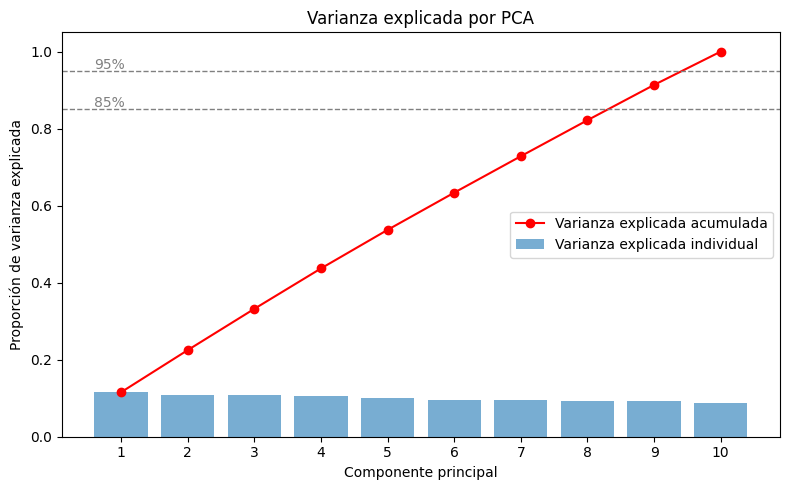

In [ ]:
# ============================================
# PASO 4.2: Gráfico de varianza explicada acumulada
# ============================================

import matplotlib.pyplot as plt

# Eje X: número de componentes
n_components = len(explained_var_ratio)
components = np.arange(1, n_components + 1)

plt.figure(figsize=(8, 5))

# 1) Barras: varianza explicada individual por cada componente
plt.bar(components,
        explained_var_ratio,
        alpha=0.6,
        label='Varianza explicada individual')

# 2) Línea roja: varianza explicada acumulada
plt.plot(components,
         explained_var_cum,
         marker='o',
         color='red',
         label='Varianza explicada acumulada')

# 3) Líneas horizontales de referencia 85 % y 95 %
plt.axhline(0.85, color='gray', linestyle='--', linewidth=1)
plt.text(0.6, 0.855, '85%', color='gray')

plt.axhline(0.95, color='gray', linestyle='--', linewidth=1)
plt.text(0.6, 0.955, '95%', color='gray')

plt.xticks(components)
plt.ylim(0, 1.05)
plt.xlabel('Componente principal')
plt.ylabel('Proporción de varianza explicada')
plt.title('Varianza explicada por PCA')
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# PCA definitivo usando 9 componentes (≈91.35 % de la varianza)
pca_final = PCA(n_components=9, random_state=42)
X_pca = pca_final.fit_transform(X_scaled)

print("Shape original:", X_scaled.shape)   # (1000, 10)
print("Shape PCA:", X_pca.shape)           # (1000, 9)

print("\nVarianza explicada por los 9 componentes:")
print(pca_final.explained_variance_ratio_.round(4))
print("Varianza explicada acumulada:", pca_final.explained_variance_ratio_.sum().round(4))


Shape original: (1000, 10)
Shape PCA: (1000, 9)

Varianza explicada por los 9 componentes:
[0.1155 0.1093 0.1072 0.1049 0.1002 0.0966 0.0947 0.0935 0.0917]
Varianza explicada acumulada: 0.9135


## Paso 4: Aplicación de PCA

### Varianza explicada y selección de componentes

Luego de aplicar PCA sobre los datos escalados, se obtuvo la siguiente varianza explicada:

- PC1..PC8: 82.18 % de la varianza acumulada.
- **PC1..PC9: 91.35 % de la varianza acumulada.**
- PC1..PC10: 100 % de la varianza.

El gráfico de varianza explicada acumulada muestra que la curva se estabiliza a partir del noveno componente y que con **9 componentes se supera el umbral recomendado (85–95 %)** de varianza total conservada. Por estrazón se decidió **retener 9 componentes principales**, lo que baja la dimensionalidad de 10 a 9 variables manteniendo aproximadamente el **91 %** de la información original.

El conjunto transformado `X_pca` tiene dimensión (1000, 9) y es la base para los análisis posteriores.


PASO 5

In [ ]:
# ============================================
# PASO 5.1: Loadings de los componentes
# ============================================

import pandas as pd
import numpy as np

# Nombres de las variables originales (en el mismo orden que X_scaled)
feature_names = X.columns  # ['Age', 'AnnualIncome', ..., 'ItemsInCart']

# Matriz de componentes de PCA: cada fila = componente, cada columna = variable
# pca_final.components_ tiene shape (9, 10)
loadings = pca_final.components_

# Convertimos a DataFrame para verlo bonito
loadings_df = pd.DataFrame(loadings,
                           columns=feature_names,
                           index=[f'PC{i}' for i in range(1, pca_final.n_components_ + 1)])

print("=== LOADINGS (cargas de las variables en cada componente) ===")
print(loadings_df.round(3))


=== LOADINGS (cargas de las variables en cada componente) ===
       Age  AnnualIncome  SpendingScore  WebVisits  DaysSinceLastPurchase  \
PC1 -0.185         0.428          0.422     -0.059                  0.433   
PC2  0.270        -0.093         -0.255      0.346                  0.239   
PC3  0.487        -0.252          0.243      0.216                 -0.363   
PC4 -0.332        -0.244          0.329      0.619                 -0.063   
PC5 -0.166        -0.129          0.514     -0.042                 -0.262   
PC6  0.571         0.334          0.005      0.050                 -0.174   
PC7 -0.030         0.615          0.048      0.487                 -0.242   
PC8  0.042         0.349         -0.011      0.054                  0.168   
PC9  0.219        -0.239          0.037      0.354                  0.628   

     EmailsOpened  AdClicks  SocialMediaInteractions  AvgSessionDuration  \
PC1         0.522     0.067                   -0.024               0.073   
PC2         0.2

In [ ]:
# Ver solo los 3 primeros componentes, ordenando por importancia absoluta del loading
for pc in ['PC1', 'PC2', 'PC3']:
    print(f"\n=== {pc} - variables con mayor peso ===")
    # Ordenar variables por valor absoluto del loading (de mayor a menor)
    pc_loadings = loadings_df.loc[pc].sort_values(key=lambda s: s.abs(), ascending=False)
    print(pc_loadings.round(3))



=== PC1 - variables con mayor peso ===
EmailsOpened               0.522
DaysSinceLastPurchase      0.433
AnnualIncome               0.428
SpendingScore              0.422
ItemsInCart               -0.361
Age                       -0.185
AvgSessionDuration         0.073
AdClicks                   0.067
WebVisits                 -0.059
SocialMediaInteractions   -0.024
Name: PC1, dtype: float64

=== PC2 - variables con mayor peso ===
AvgSessionDuration         0.622
SocialMediaInteractions    0.437
WebVisits                  0.346
Age                        0.270
SpendingScore             -0.255
EmailsOpened               0.252
DaysSinceLastPurchase      0.239
AdClicks                  -0.146
ItemsInCart                0.119
AnnualIncome              -0.093
Name: PC2, dtype: float64

=== PC3 - variables con mayor peso ===
Age                        0.487
AdClicks                   0.423
DaysSinceLastPurchase     -0.363
SocialMediaInteractions   -0.352
ItemsInCart               -0.283
Ann

## Paso 5: Interpretación de los componentes principales

### 5.1 Análisis de loadings

A partir de los loadings de PCA se observaron estos patrones:

- **PC1**: presenta cargas altas y positivas en `EmailsOpened`, `DaysSinceLastPurchase`, `AnnualIncome` y `SpendingScore`, y una carga negativa importante en `ItemsInCart`. Esto indica una dimensión asociada a la **relación económica y respuesta a correos**, donde los clientes con mayor capacidad y nivel de gasto, que responden más correos, pero que tienden a hacer compras con carritos más pequeños y con menor recencia(la recencia es el tiempo transcurrido desde el ultimo contacto con la marca, alta recencia → ha transcurrido poco tiempo, baja recencia → ha transcurrido mucho tiempo).

- **PC2**: tiene cargas altas y positivas en `AvgSessionDuration`, `SocialMediaInteractions` y `WebVisits`, junto con aportes de `Age` y `EmailsOpened`. Representa un **nivel de interacción digital y navegación**, es decir, qué tanto tiempo y actividad tienen los clientes en los canales online. Un valor alto en PC2 indica clientes con fuerte actividad digital (más visitas, más tiempo en el sitio y más interacciones en redes), mientras que un valor bajo indica clientes menos activos online, relativamente más asociados al gasto/ingreso que al uso intensivo de los canales digitales.

- **PC3**: muestra pesos positivos en `Age`, `AdClicks`, `SpendingScore`, `WebVisits` y `EmailsOpened`, frente a cargas negativas en `DaysSinceLastPurchase`, `SocialMediaInteractions`, `ItemsInCart` y `AnnualIncome`. Este componente combina aspectos de **perfil demográfico y respuesta a campañas** con la **recencia de compra**.Un valor alto de PC3 indica clientes de mayor edad que responden más a los anuncios (más clics) y han comprado más recientemente, mientras que un valor bajo describe clientes más jóvenes, con mayor actividad en redes sociales y carritos algo más grandes, pero con compras menos recientes.

### 5.2 Bautizo de los componentes

Tomando en cuenta lo anterior, propongo estos nombres de negocio:

- **PC1 – “Intensidad de relación económica por email”**.  
- **PC2 – “Nivel de interacción digital y de navegación”**.  
- **PC3 – “Perfil demográfico y respuesta a campañas con recencia alta”**.

Estos nombres asocian los componentes matemáticos de PCA con conceptos que el negocio pueda comprender, cumpliendo el objetivo de que el modelo sea interpretable.
